# Capstone Project: Penguin Species Prediction and Grouping

**Yuva Intern / NSDC - Week 6: Integrative Capstone Project**

In this project I go through the full data science pipeline on one dataset: getting the data, cleaning it, exploring it, building unsupervised and supervised models, evaluating them and writing down my conclusions.

**Dataset:** Palmer Penguins (public dataset, available through the seaborn library / seaborn-data GitHub repository). It has measurements of 344 penguins from three species living on three islands in Antarctica.

**Problem statement:** Can we predict the species of a penguin (Adelie, Chinstrap or Gentoo) from its body measurements, island and sex? And if we ignore the species labels completely, do the measurements still form natural groups?

**Plan:**
1. Data collection
2. Data cleaning
3. Exploratory data analysis (EDA)
4. Unsupervised learning (K-Means, Hierarchical clustering, PCA)
5. Supervised learning (4 classifiers, cross validation, tuning)
6. Evaluation
7. Conclusions and recommendations

## 1. Setup

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay,
                             silhouette_score, adjusted_rand_score)
from scipy.cluster.hierarchy import dendrogram, linkage

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

RANDOM_STATE = 42          # fixed so my results are the same every time I run the notebook
os.makedirs("figures", exist_ok=True)
results = {}               # I will store important numbers here and save them at the end

## 2. Data Collection

The data is loaded from the file `penguins.csv`. This file is simply the seaborn Penguins dataset saved as CSV, so the notebook also works without internet. If the file is not found, the code loads the same dataset directly from seaborn.

In [2]:
if os.path.exists("penguins.csv"):
    df = pd.read_csv("penguins.csv")
    print("Loaded from local penguins.csv")
else:
    df = sns.load_dataset("penguins")
    print("Loaded from seaborn")

print("Shape:", df.shape)
df.head()

Loaded from local penguins.csv
Shape: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


In [4]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [5]:
# categorical columns
for col in ["species", "island", "sex"]:
    print(df[col].value_counts(dropna=False))
    print()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

sex
Male      168
Female    165
NaN        11
Name: count, dtype: int64



**What I see:** 344 rows and 7 columns. Four columns are numeric measurements (bill length, bill depth, flipper length, body mass) and three are categories (species, island, sex). The target for the supervised part will be `species`.

## 3. Data Cleaning

First I check missing values, duplicate rows and outliers.

In [6]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())

Missing values per column:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Duplicate rows: 0


In [7]:
num_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

# rows where ALL four measurements are missing
all_missing = df[num_cols].isnull().all(axis=1)
print("Rows with no measurements at all:", all_missing.sum())
df[all_missing]

Rows with no measurements at all: 2


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


Two rows have no measurements at all (and no sex). They carry no useful information, so I drop them. The remaining missing values are in `sex` only, so I will keep those rows and fill the gap later inside the modelling pipeline (using the most frequent value learned from the training data only). This avoids data leakage from the test set.

In [8]:
df_clean = df[~all_missing].copy().reset_index(drop=True)
print("Shape after dropping empty rows:", df_clean.shape)
print()
print(df_clean.isnull().sum())

Shape after dropping empty rows: (342, 7)

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  9
dtype: int64


bill_length_mm: 0 outliers (limits 25.3 to 62.4)
bill_depth_mm: 0 outliers (limits 10.9 to 23.3)
flipper_length_mm: 0 outliers (limits 155.5 to 247.5)
body_mass_g: 0 outliers (limits 1750.0 to 6550.0)


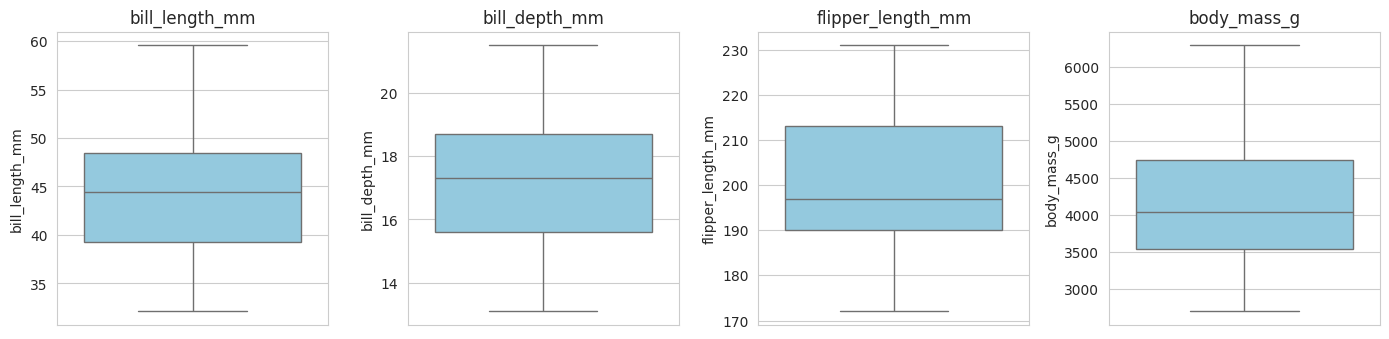

In [9]:
# check outliers with the IQR rule
outlier_counts = {}
for col in num_cols:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df_clean[col] < low) | (df_clean[col] > high)).sum()
    outlier_counts[col] = int(n_out)
    print(f"{col}: {n_out} outliers (limits {low:.1f} to {high:.1f})")

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df_clean[col], ax=ax, color="skyblue")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("figures/01_boxplots_outliers.png", dpi=120, bbox_inches="tight")
plt.show()

**Decision on outliers:** The IQR rule finds no outliers in these columns, so there is nothing to remove. This is a good sign, the data looks like real measurements without typing mistakes.

Cleaning summary: 2 empty rows removed, no duplicates, no outliers, 9 missing `sex` values left to be imputed in the pipeline.

In [10]:
results["rows_raw"] = int(df.shape[0])
results["rows_clean"] = int(df_clean.shape[0])
results["missing_raw"] = {k: int(v) for k, v in df.isnull().sum().items()}
results["missing_clean"] = {k: int(v) for k, v in df_clean.isnull().sum().items()}
results["duplicates"] = int(df.duplicated().sum())
results["outliers"] = outlier_counts

## 4. Exploratory Data Analysis (EDA)

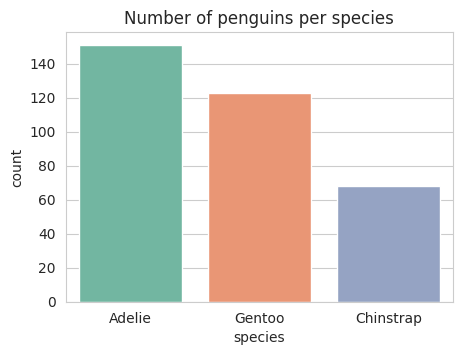

species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64


In [11]:
# how many penguins of each species?
order = df_clean["species"].value_counts().index
plt.figure(figsize=(5, 3.5))
sns.countplot(data=df_clean, x="species", order=order, palette="Set2")
plt.title("Number of penguins per species")
plt.savefig("figures/02_species_count.png", dpi=120, bbox_inches="tight")
plt.show()
print(df_clean["species"].value_counts())
results["species_counts"] = {k: int(v) for k, v in df_clean["species"].value_counts().items()}

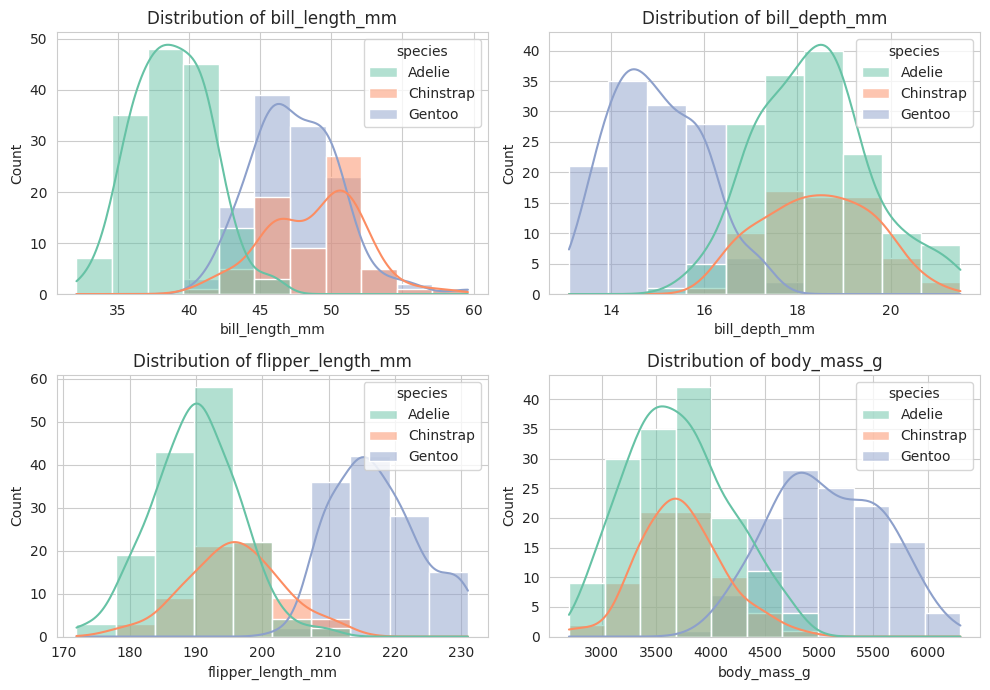

In [12]:
# distribution of each measurement
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(df_clean, x=col, hue="species", kde=True, ax=ax, palette="Set2")
    ax.set_title("Distribution of " + col)
plt.tight_layout()
plt.savefig("figures/03_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

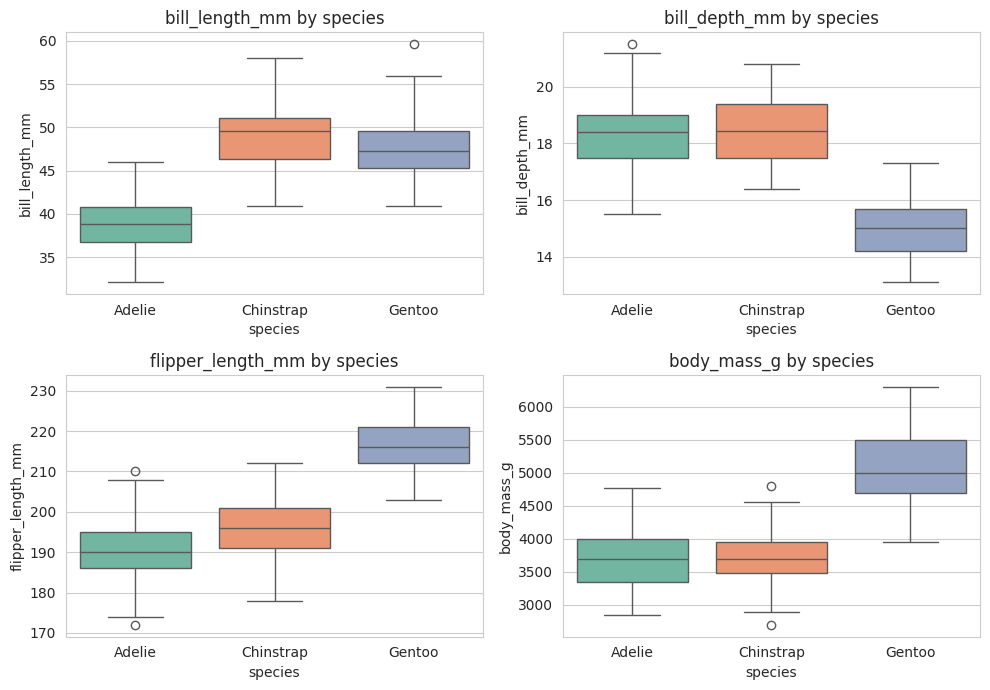

           bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
species                                                                 
Adelie               38.8           18.3              190.0       3700.7
Chinstrap            48.8           18.4              195.8       3733.1
Gentoo               47.5           15.0              217.2       5076.0


In [13]:
# measurements by species
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(data=df_clean, x="species", y=col, ax=ax, palette="Set2")
    ax.set_title(col + " by species")
plt.tight_layout()
plt.savefig("figures/04_boxplots_by_species.png", dpi=120, bbox_inches="tight")
plt.show()

print(df_clean.groupby("species")[num_cols].mean().round(1))
results["species_means"] = df_clean.groupby("species")[num_cols].mean().round(1).to_dict()

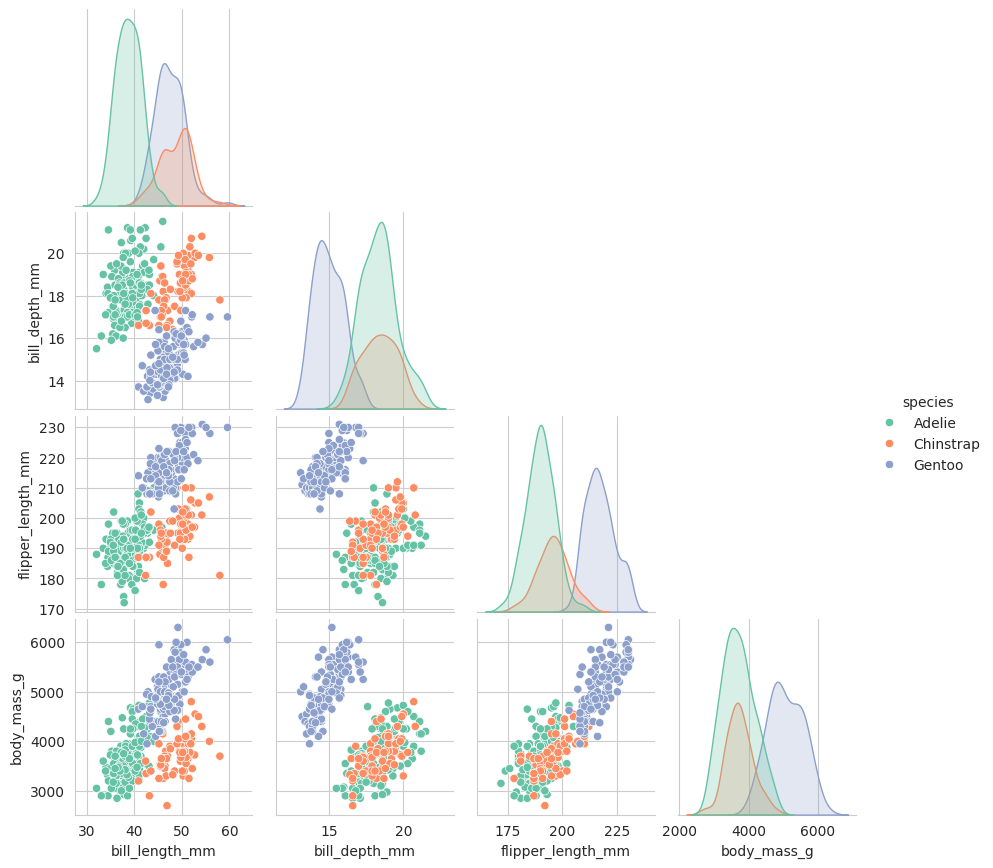

In [14]:
# pairplot: how do the features relate to each other?
g = sns.pairplot(df_clean, vars=num_cols, hue="species", palette="Set2", corner=True, height=2.2)
g.savefig("figures/05_pairplot.png", dpi=110, bbox_inches="tight")
plt.show()

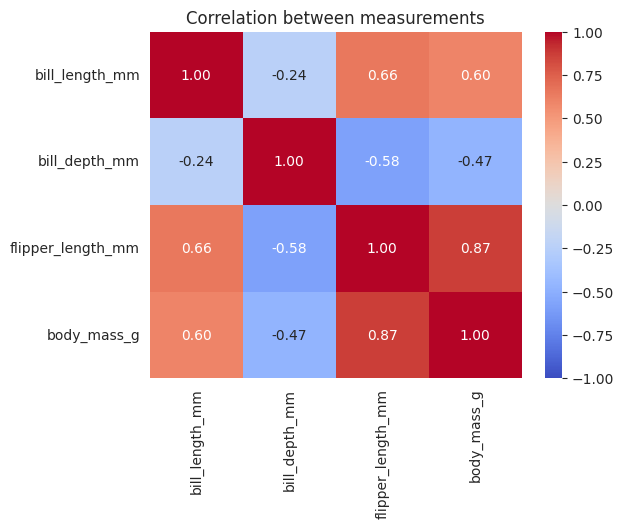

In [15]:
# correlation heatmap
corr = df_clean[num_cols].corr()
plt.figure(figsize=(6, 4.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation between measurements")
plt.savefig("figures/06_correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()
results["corr"] = corr.round(2).to_dict()

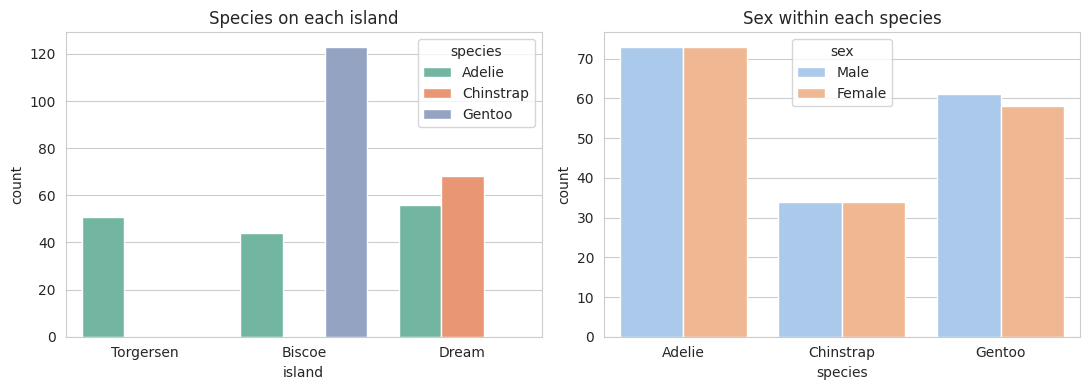

species    Adelie  Chinstrap  Gentoo
island                              
Biscoe         44          0     123
Dream          56         68       0
Torgersen      51          0       0


In [16]:
# island and sex
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=df_clean, x="island", hue="species", palette="Set2", ax=axes[0])
axes[0].set_title("Species on each island")
sns.countplot(data=df_clean.dropna(subset=["sex"]), x="species", hue="sex", palette="pastel", ax=axes[1])
axes[1].set_title("Sex within each species")
plt.tight_layout()
plt.savefig("figures/07_island_and_sex.png", dpi=120, bbox_inches="tight")
plt.show()
print(pd.crosstab(df_clean["island"], df_clean["species"]))
results["island_species"] = pd.crosstab(df_clean["island"], df_clean["species"]).to_dict()

**Key findings from EDA**
- The classes are not perfectly balanced: Adelie is the biggest group and Chinstrap the smallest, so I will use stratified splits and look at precision/recall/F1 and not only accuracy.
- Gentoo penguins are clearly different: they are much heavier and have much longer flippers than the other two species.
- Adelie and Chinstrap have similar body mass and flipper length, but Chinstrap has a longer bill, so bill length helps to separate them.
- Flipper length and body mass are strongly positively correlated, so these two carry similar information.
- Island matters: Gentoo lives only on Biscoe, Chinstrap only on Dream, while Adelie is found on all three islands.
- Within each species the male penguins are larger than the females, so sex explains some of the spread inside a species.

## 5. Unsupervised Learning

Here I pretend I do not know the species and let the algorithms find groups using only the four numeric measurements. Features are scaled first, because K-Means and hierarchical clustering use distances and body mass (in grams) would otherwise dominate everything.

In [17]:
X_num = df_clean[num_cols].values
X_scaled = StandardScaler().fit_transform(X_num)
y_species = df_clean["species"].values
print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (342, 4)


### 5.1 K-Means: choosing k

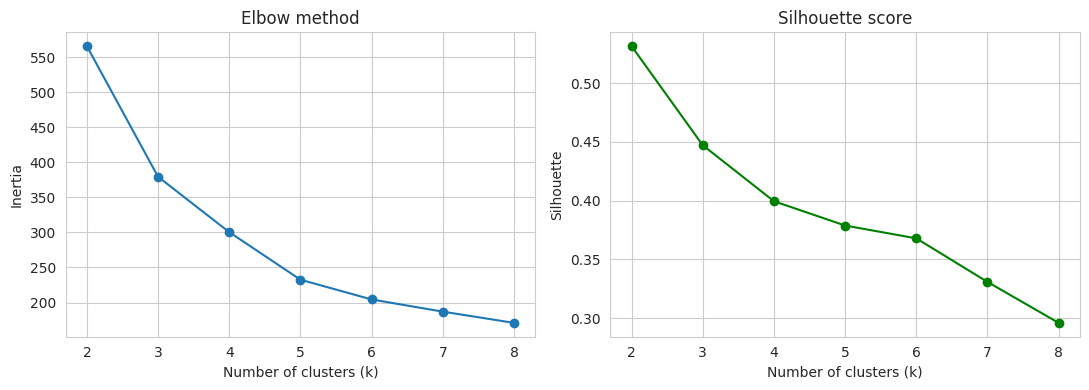

k=2  inertia=565.7  silhouette=0.532
k=3  inertia=379.4  silhouette=0.447
k=4  inertia=300.4  silhouette=0.400
k=5  inertia=232.6  silhouette=0.379
k=6  inertia=204.4  silhouette=0.368
k=7  inertia=187.0  silhouette=0.331
k=8  inertia=171.0  silhouette=0.296


In [18]:
ks = range(2, 9)
inertias, sil_scores = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(ks), inertias, marker="o")
axes[0].set_title("Elbow method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[1].plot(list(ks), sil_scores, marker="o", color="green")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.savefig("figures/08_kmeans_elbow_silhouette.png", dpi=120, bbox_inches="tight")
plt.show()

for k, i, s in zip(ks, inertias, sil_scores):
    print(f"k={k}  inertia={i:.1f}  silhouette={s:.3f}")
results["kmeans_k_scan"] = {int(k): {"inertia": round(float(i), 1), "silhouette": round(float(s), 3)}
                            for k, i, s in zip(ks, inertias, sil_scores)}

The silhouette score is highest for a small number of clusters, and the elbow in the inertia curve is around k = 2 to 3. The score is highest at k = 2 because Gentoo is so different from the other two species. Since the three species overlap a bit (Adelie and Chinstrap), I also test k = 3 and compare the clusters with the real species to see which choice makes more sense.

In [19]:
cluster_results = {}
for k in [2, 3]:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_scaled)
    sil = silhouette_score(X_scaled, km.labels_)
    ari = adjusted_rand_score(y_species, km.labels_)
    cluster_results[k] = {"silhouette": round(float(sil), 3), "ari": round(float(ari), 3)}
    print(f"K-Means k={k}: silhouette={sil:.3f}, adjusted rand index vs species={ari:.3f}")

km3 = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(X_scaled)
df_clean["kmeans_cluster"] = km3.labels_
print()
print(pd.crosstab(df_clean["species"], df_clean["kmeans_cluster"], rownames=["species"], colnames=["cluster"]))
results["kmeans"] = cluster_results
results["kmeans3_crosstab"] = pd.crosstab(df_clean["species"], df_clean["kmeans_cluster"]).to_dict()

K-Means k=2: silhouette=0.532, adjusted rand index vs species=0.655
K-Means k=3: silhouette=0.447, adjusted rand index vs species=0.793

cluster     0    1    2
species                
Adelie     24    0  127
Chinstrap  63    0    5
Gentoo      0  123    0


### 5.2 PCA for visualisation

Explained variance ratio: [0.688 0.193]
Total explained by 2 components: 0.882


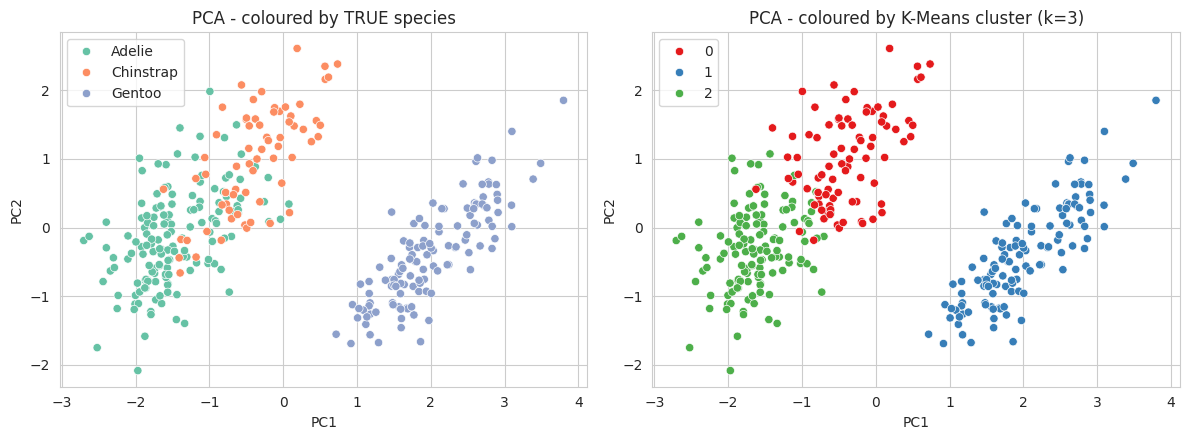

                    PC1   PC2
bill_length_mm     0.46  0.60
bill_depth_mm     -0.40  0.80
flipper_length_mm  0.58  0.00
body_mass_g        0.55  0.08


In [20]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print("Explained variance ratio:", pca.explained_variance_ratio_.round(3))
print("Total explained by 2 components:", round(pca.explained_variance_ratio_.sum(), 3))
results["pca_var"] = [round(float(v), 3) for v in pca.explained_variance_ratio_]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_species, palette="Set2", ax=axes[0])
axes[0].set_title("PCA - coloured by TRUE species")
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=km3.labels_, palette="Set1", ax=axes[1])
axes[1].set_title("PCA - coloured by K-Means cluster (k=3)")
for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig("figures/09_pca_species_vs_kmeans.png", dpi=120, bbox_inches="tight")
plt.show()

loadings = pd.DataFrame(pca.components_.T, index=num_cols, columns=["PC1", "PC2"]).round(2)
print(loadings)
results["pca_loadings"] = loadings.to_dict()

### 5.3 Hierarchical clustering

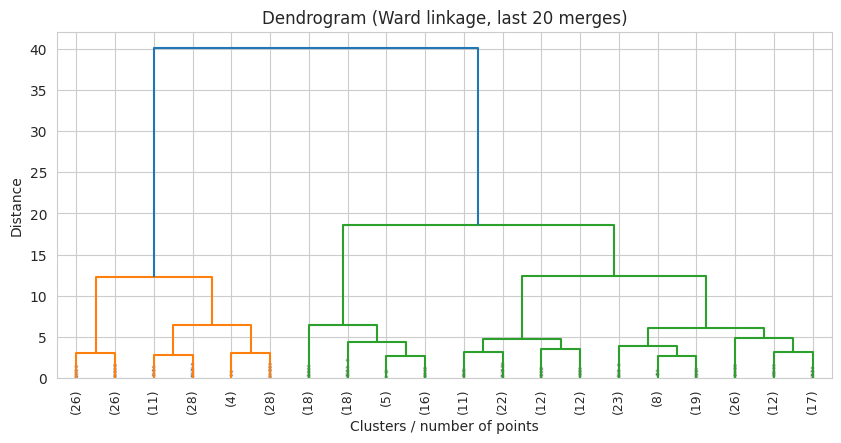

Hierarchical (k=3): silhouette=0.454, adjusted rand index vs species=0.916

cluster      0    1   2
species                
Adelie     151    0   0
Chinstrap   11    0  57
Gentoo       0  123   0


In [21]:
Z = linkage(X_scaled, method="ward")
plt.figure(figsize=(10, 4.5))
dendrogram(Z, truncate_mode="lastp", p=20, leaf_rotation=90, leaf_font_size=9, show_contracted=True)
plt.title("Dendrogram (Ward linkage, last 20 merges)")
plt.xlabel("Clusters / number of points")
plt.ylabel("Distance")
plt.savefig("figures/10_dendrogram.png", dpi=120, bbox_inches="tight")
plt.show()

agg = AgglomerativeClustering(n_clusters=3, linkage="ward").fit(X_scaled)
sil_h = silhouette_score(X_scaled, agg.labels_)
ari_h = adjusted_rand_score(y_species, agg.labels_)
print(f"Hierarchical (k=3): silhouette={sil_h:.3f}, adjusted rand index vs species={ari_h:.3f}")
print()
print(pd.crosstab(y_species, agg.labels_, rownames=["species"], colnames=["cluster"]))
results["hierarchical"] = {"silhouette": round(float(sil_h), 3), "ari": round(float(ari_h), 3)}
results["hier_crosstab"] = pd.crosstab(y_species, agg.labels_).to_dict()

**What the unsupervised part tells me:** The measurements form natural groups even without labels. Gentoo separates cleanly in both methods (all 123 Gentoo penguins end up together). Adelie and Chinstrap overlap, so some penguins land in the "wrong" cluster. Hierarchical clustering (Ward) matched the real species better than K-Means (adjusted rand index 0.916 vs 0.793): K-Means mixed 24 Adelie penguins into the mostly-Chinstrap cluster, while hierarchical clustering only placed 11 Chinstrap penguins in the Adelie cluster. Silhouette scores are similar (0.447 and 0.454). This hints that a supervised model should do very well, with the only possible confusion between Adelie and Chinstrap.

## 6. Supervised Learning (Classification)

**Target:** `species`. **Features:** the four measurements plus `island` and `sex`.

Steps:
1. Split data into train (80%) and test (20%) using a stratified split so each species keeps the same proportion.
2. Build a preprocessing pipeline: numeric columns get median imputation + scaling, categorical columns get most-frequent imputation + one-hot encoding. Putting it inside a Pipeline means the imputer and scaler only learn from the training folds (no leakage).
3. Compare 4 models with 5-fold cross validation on the training data.
4. Tune the best candidates with GridSearchCV.
5. Evaluate the final model once on the untouched test set.

In [22]:
feature_cols = num_cols + ["island", "sex"]
X = df_clean[feature_cols]
y = df_clean["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])
print()
print("Train class share:")
print(y_train.value_counts(normalize=True).round(3))
print("Test class share:")
print(y_test.value_counts(normalize=True).round(3))
results["train_size"] = int(X_train.shape[0])
results["test_size"] = int(X_test.shape[0])

Train size: 273  Test size: 69

Train class share:
species
Adelie       0.443
Gentoo       0.359
Chinstrap    0.198
Name: proportion, dtype: float64
Test class share:
species
Adelie       0.435
Gentoo       0.362
Chinstrap    0.203
Name: proportion, dtype: float64


In [23]:
cat_cols = ["island", "sex"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), num_cols),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
])

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

### 6.1 Cross validation of the four models

In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_table = {}
for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy")
    cv_table[name] = {"cv_mean": round(float(scores.mean()), 4), "cv_std": round(float(scores.std()), 4)}
    print(f"{name:20s} CV accuracy = {scores.mean():.4f} (+/- {scores.std():.4f})")
results["cv"] = cv_table

Logistic Regression  CV accuracy = 0.9927 (+/- 0.0090)
KNN                  CV accuracy = 0.9853 (+/- 0.0138)


Random Forest        CV accuracy = 0.9818 (+/- 0.0199)


Gradient Boosting    CV accuracy = 0.9780 (+/- 0.0138)


### 6.2 Hyperparameter tuning (GridSearchCV)

In [25]:
grids = {
    "Logistic Regression": {"model__C": [0.01, 0.1, 1, 10, 100]},
    "Random Forest": {"model__n_estimators": [100, 200],
                      "model__max_depth": [None, 3, 5],
                      "model__min_samples_split": [2, 5]},
}

tuned = {}
for name, grid in grids.items():
    pipe = Pipeline([("prep", preprocessor), ("model", models[name])])
    gs = GridSearchCV(pipe, grid, cv=cv, scoring="accuracy", n_jobs=-1)
    gs.fit(X_train, y_train)
    tuned[name] = gs
    print(name)
    print("  best params:", gs.best_params_)
    print("  best CV accuracy:", round(gs.best_score_, 4))
    print()
results["tuning"] = {n: {"best_params": {k: (v if v is not None else "None") for k, v in g.best_params_.items()},
                         "best_cv": round(float(g.best_score_), 4)} for n, g in tuned.items()}

Logistic Regression
  best params: {'model__C': 1}
  best CV accuracy: 0.9927



Random Forest
  best params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}
  best CV accuracy: 0.9818



### 6.3 Test set results for all models

In [26]:
rows = []
final_models = {}
for name, model in models.items():
    if name in tuned:
        fitted = tuned[name].best_estimator_
        label = name + " (tuned)"
    else:
        fitted = Pipeline([("prep", preprocessor), ("model", model)]).fit(X_train, y_train)
        label = name
    final_models[label] = fitted
    pred = fitted.predict(X_test)
    rows.append({
        "Model": label,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision (macro)": precision_score(y_test, pred, average="macro"),
        "Recall (macro)": recall_score(y_test, pred, average="macro"),
        "F1 (macro)": f1_score(y_test, pred, average="macro"),
    })

score_df = pd.DataFrame(rows).set_index("Model").round(4)
score_df

,Accuracy,Precision (macro),Recall (macro),F1 (macro)
Model,,,,
Logistic Regression (tuned),1.0,1.0,1.0,1.0
KNN,1.0,1.0,1.0,1.0
Random Forest (tuned),1.0,1.0,1.0,1.0
Gradient Boosting,1.0,1.0,1.0,1.0


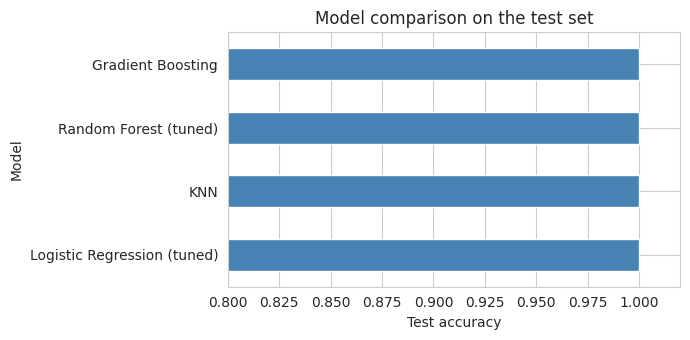

In [27]:
score_df["Accuracy"].sort_values().plot(kind="barh", figsize=(7, 3.5), color="steelblue")
plt.xlim(0.8, 1.02)
plt.xlabel("Test accuracy")
plt.title("Model comparison on the test set")
plt.tight_layout()
plt.savefig("figures/11_model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
results["test_scores"] = score_df.to_dict(orient="index")

**Reading the table:** All four models score 100% on the test set. That sounds amazing, but the test set has only 69 penguins, so it cannot separate good models from very good models. The cross validation scores on the training data give a better comparison: Logistic Regression 0.9927, KNN 0.9853, Random Forest 0.9818, Gradient Boosting 0.9780. The differences are small (about one penguin per fold), so I should not claim that one model is clearly better than the others.

### 6.4 Final model: detailed evaluation

I choose the final model using the **cross-validation score** from the training data (not the test score), so the test set stays an honest final check.

Final model chosen by CV score: Logistic Regression

              precision    recall  f1-score   support

      Adelie      1.000     1.000     1.000        30
   Chinstrap      1.000     1.000     1.000        14
      Gentoo      1.000     1.000     1.000        25

    accuracy                          1.000        69
   macro avg      1.000     1.000     1.000        69
weighted avg      1.000     1.000     1.000        69



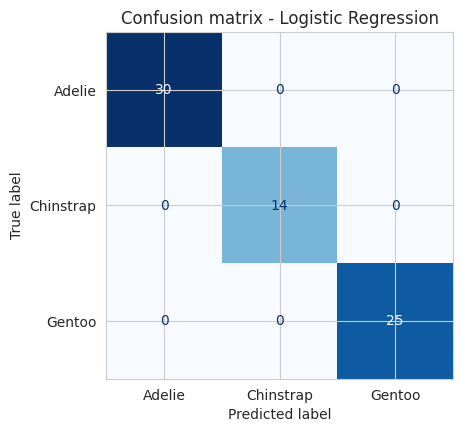

In [28]:
best_name = max(tuned, key=lambda n: tuned[n].best_score_)
print("Final model chosen by CV score:", best_name)
final_pipe = tuned[best_name].best_estimator_
y_pred = final_pipe.predict(X_test)

print()
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred, labels=final_pipe.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=final_pipe.classes_)
fig, ax = plt.subplots(figsize=(5, 4.5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion matrix - " + best_name)
plt.savefig("figures/12_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

results["final_model"] = best_name
results["final_test_accuracy"] = round(float(accuracy_score(y_test, y_pred)), 4)
results["final_confusion"] = cm.tolist()
results["classes"] = list(final_pipe.classes_)
results["final_report"] = classification_report(y_test, y_pred, output_dict=True)

In [29]:
# wrong predictions, if any
wrong = X_test[y_pred != y_test].copy()
wrong["true"] = y_test[y_pred != y_test]
wrong["predicted"] = y_pred[y_pred != y_test]
print("Number of wrong predictions:", len(wrong), "out of", len(y_test))
wrong

Number of wrong predictions: 0 out of 69


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island,sex,true,predicted


### 6.5 Is the result stable? (cross validation on the full data)

In [30]:
# a test set of only ~69 rows is small, so I also check the final model with repeated CV on all data
from sklearn.model_selection import RepeatedStratifiedKFold
rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)
from sklearn.base import clone
all_scores = cross_val_score(clone(final_pipe), X, y, cv=rcv, scoring="accuracy")
print(f"Repeated 5-fold CV accuracy on full data: {all_scores.mean():.4f} (+/- {all_scores.std():.4f})")
results["repeated_cv"] = {"mean": round(float(all_scores.mean()), 4), "std": round(float(all_scores.std()), 4)}

Repeated 5-fold CV accuracy on full data: 0.9936 (+/- 0.0073)


The repeated cross validation on all the data gives about 99.4% accuracy (std 0.7%). This is a more honest estimate than the 100% on one small test split: on new penguins I would expect roughly 99% accuracy, so one or two mistakes in a hundred, most likely between Adelie and Chinstrap.

### 6.6 Which features matter? (Random Forest importance)

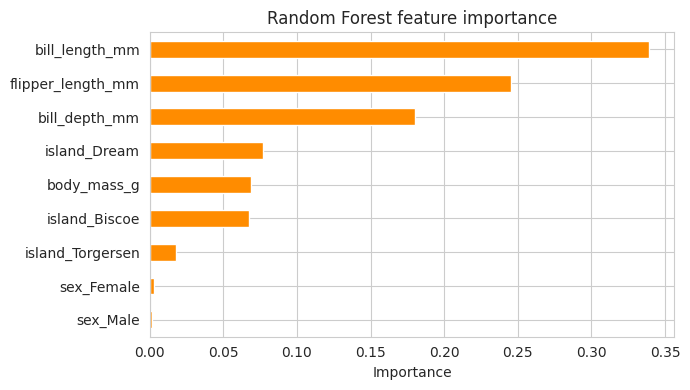

bill_length_mm       0.339
flipper_length_mm    0.245
bill_depth_mm        0.180
island_Dream         0.077
body_mass_g          0.069
island_Biscoe        0.067
island_Torgersen     0.018
sex_Female           0.003
sex_Male             0.002
dtype: float64


In [31]:
rf_pipe = tuned["Random Forest"].best_estimator_
feat_names = rf_pipe.named_steps["prep"].get_feature_names_out()
feat_names = [n.split("__")[1] for n in feat_names]
imp = pd.Series(rf_pipe.named_steps["model"].feature_importances_, index=feat_names).sort_values()

imp.plot(kind="barh", figsize=(7, 4), color="darkorange")
plt.title("Random Forest feature importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("figures/13_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()
print(imp.sort_values(ascending=False).round(3))
results["feature_importance"] = {k: round(float(v), 3) for k, v in imp.sort_values(ascending=False).items()}

**Feature importance:** Bill length (0.339), flipper length (0.245) and bill depth (0.180) are the most important features. Body mass has a low importance (0.069) even though Gentoo penguins are much heavier, because it is strongly correlated with flipper length (0.87) so the two share the credit. Island is also used (the three island columns add up to about 0.16), which makes sense because Chinstrap is only found on Dream and Gentoo only on Biscoe. Sex is almost unused (about 0.005 in total): sex changes the size inside a species but does not change which species it is.

## 7. Save results

In [32]:
with open("results.json", "w") as f:
    json.dump(results, f, indent=2, default=str)
print("Saved results.json and figures folder")
print(sorted(os.listdir("figures")))

Saved results.json and figures folder
['01_boxplots_outliers.png', '02_species_count.png', '03_distributions.png', '04_boxplots_by_species.png', '05_pairplot.png', '06_correlation_heatmap.png', '07_island_and_sex.png', '08_kmeans_elbow_silhouette.png', '09_pca_species_vs_kmeans.png', '10_dendrogram.png', '11_model_comparison.png', '12_confusion_matrix.png', '13_feature_importance.png']


## 8. Conclusions, Recommendations and Reflection

### Summary of the pipeline
| Phase | What I did | Result |
|---|---|---|
| Data collection | Palmer Penguins dataset (seaborn / seaborn-data) | 344 rows, 7 columns |
| Cleaning | Removed 2 rows with no measurements, checked duplicates and outliers | 342 rows, 0 duplicates, 0 outliers, 9 missing `sex` values imputed inside the pipeline |
| EDA | Distributions, box plots, pair plot, correlation, island and sex plots | Gentoo clearly different, Adelie and Chinstrap overlap |
| Unsupervised | K-Means, PCA, Hierarchical clustering | Hierarchical (Ward, k=3) matched species best: adjusted rand index 0.916 vs 0.793 for K-Means |
| Supervised | Logistic Regression, KNN, Random Forest, Gradient Boosting with 5-fold CV and GridSearchCV | CV accuracy between 0.978 and 0.993, test accuracy 100% for all models |
| Evaluation | Accuracy, precision, recall, F1, confusion matrix, repeated CV | Final model Logistic Regression, repeated CV accuracy 0.994 |

### Insights and recommendations
- Species can be predicted from simple body measurements with about 99% accuracy. Bill length and flipper length are the most useful features.
- A researcher in the field could identify a penguin species quickly from just a bill and flipper measurement, without needing a more expensive method.
- Because a simple Logistic Regression works as well as the more complex models, it is the better choice here: it is fast, easy to explain and less likely to overfit on a small dataset.

### Limitations
- The dataset is small (342 penguins) and the species are quite different from each other, so this is an easy classification problem. The results may not hold for harder problems.
- The 100% test accuracy comes from a test set of only 69 rows. The repeated cross validation score (about 99.4%) is more realistic.
- The `island` feature is almost a shortcut for the species (Chinstrap only lives on Dream, Gentoo only on Biscoe). A model that depends on it may not work for penguins from a new location.
- The data comes from only three islands and a few years, so it may not represent all penguin populations.

### What further analysis could be done
- Train the models without the `island` feature to check how well species can be predicted from body measurements alone.
- Try other models such as SVM, and compare them with statistical tests, instead of only looking at the mean score.
- Use the same data for a regression task (predict body mass from flipper length and bill size).
- Collect more data from more islands and years to test whether the model generalises.

### Reflection: challenges and successes
**Challenges**
- Choosing the number of clusters was not straightforward. The silhouette score was highest for k = 2 (0.532), but k = 3 matched the real species better, so I had to explain both choices instead of trusting one number.
- Avoiding data leakage: I put imputation, scaling and encoding inside a Pipeline so that they are fitted only on the training folds.
- 100% test accuracy looked suspicious at first. I handled it by using cross validation and repeated cross validation, and by explaining that the small test set is the reason.

**Successes**
- The full pipeline runs from start to end in one notebook and gives the same results each time (fixed random state).
- The unsupervised results agree with the supervised ones: Gentoo is easy to separate, while Adelie and Chinstrap are the only pair that overlaps.
- The feature importance results agree with what I saw in the EDA plots, so the analysis is consistent from beginning to end.